In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('C:/3курс/DS/student.csv')
df

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,5001,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,1,5002,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,2,5003,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,3,5004,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,4,5005,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,140,5141,22,Female,State,50%,Yes,Yes,Private,0,Always,No,Yes,No,Yes,CC
141,141,5142,18,Female,State,75%,No,No,Private,0,Never,No,Yes,Yes,No,CC
142,142,5143,18,Female,Private,75%,No,No,Private,0,Always,Yes,No,No,No,AA
143,143,5144,22,Female,State,75%,Yes,Yes,Bus,12,Sometimes,No,Yes,No,Yes,CB


In [66]:
list_columns = ['Student_Age', 'Sex', 'High_School_Type', 'Scholarship', 'Additional_Work', 'Sports_activity', 'Transportation','Weekly_Study_Hours','Attendance', 'Reading','Notes', 'Listening_in_Class', 'Project_work', 'Grade']
for i in list_columns:
    print(df[i].unique())

[21 20 18 22 19 26 25 24 23]
['Male' 'Female']
['Other' 'State' 'Private']
['50%' '75%' '100%' '25%' nan]
['Yes' 'No']
['No' 'Yes']
['Private' 'Bus']
[ 0  2 12  8]
['Always' 'Never' 'Sometimes' '3']
['Yes' 'No']
['Yes' 'No' '6']
['No' 'Yes' '6']
['No' 'Yes']
['AA' 'BA' 'CC' 'Fail' 'BB' 'CB' 'DD' 'DC']


In [67]:
df = df.drop(columns=['Id'])

In [68]:
df['High_School_Type'] = df['High_School_Type'].map({'Other': 2, 'State': 1, 'Private': 0}).astype(float)
df['Sex'] = df['Sex'].map({'Male': 0, 'Female': 1}).astype(float)
df['Scholarship'] = df['Scholarship'].map({'50%': 0.5, '75%': 0.75, '100%': 1, '25%': 0.25}).astype(float)
df['Additional_Work'] = df['Additional_Work'].map({'Yes': 1, 'No': 0}).astype(float)
df['Sports_activity'] = df['Sports_activity'].map({'Yes': 1, 'No': 0}).astype(float)
df['Transportation'] = df['Transportation'].map({'Private': 0, 'Bus': 1}).astype(float)
df['Attendance'] = df['Attendance'].map({'Always': 1, 'Never': 2, 'Sometimes': 0.5, '3': 0}).astype(float)
df['Reading'] = df['Reading'].map({'Yes': 1, 'No': 0}).astype(float)
df['Notes'] = df['Notes'].map({'Yes': 1, 'No': 2, '6': 0}).astype(float)
df['Listening_in_Class'] = df['Listening_in_Class'].map({'Yes': 2, 'No': 1, '6': 0}).astype(float)
df['Project_work'] = df['Project_work'].map({'Yes': 1, 'No': 0}).astype(float)
df['Grade'] = df['Grade'].map({'AA': 0, 'BA': 1, 'CC': 2, 'Fail': 3, 'BB': 4, 'CB': 5, 'DD': 6, 'DC': 7}).astype(float)

In [69]:
df = df.dropna(subset=["Scholarship"])
df = df.drop(columns=['Unnamed: 0'])

In [70]:
df.head()

,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,21,0.0,2.0,0.5,1.0,0.0,0.0,0,1.0,1.0,1.0,1.0,0.0,0.0
1,20,0.0,2.0,0.5,1.0,0.0,0.0,0,1.0,1.0,2.0,2.0,1.0,0.0
2,21,0.0,1.0,0.5,0.0,0.0,0.0,2,2.0,0.0,2.0,1.0,1.0,0.0
3,18,1.0,0.0,0.5,1.0,0.0,1.0,2,1.0,0.0,1.0,1.0,0.0,0.0
4,22,0.0,0.0,0.5,0.0,0.0,1.0,12,1.0,1.0,2.0,2.0,1.0,0.0


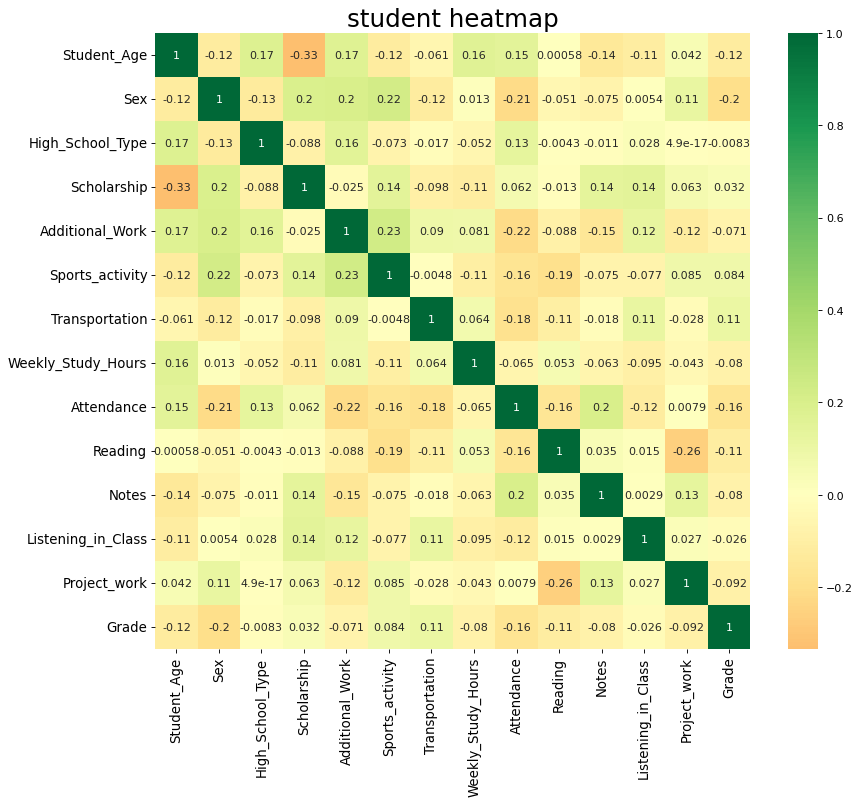

In [71]:
heatdf = df
plt.figure(figsize = (12,10), dpi = 80)
sns.heatmap(heatdf.corr(), xticklabels = heatdf.corr().columns, yticklabels = heatdf.corr().columns, cmap = 'RdYlGn', center = 0, annot = True)
plt.title('student heatmap', fontsize = 22)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

In [72]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [73]:
X = df.drop('Grade', axis=1)
y = df['Grade']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### GridSearchCV

In [76]:
# Logistic Regression

param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg']
}
lr = LogisticRegression(max_iter=1000, random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_lr.best_params_}")
print(f"Лучшая точность CV: {grid_lr.best_score_:.4f}")
print(f"Тестовая точность: {accuracy_score(y_test, grid_lr.predict(X_test_scaled)):.4f}")

Лучшие параметры: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучшая точность CV: 0.1913
Тестовая точность: 0.2414


In [77]:
# Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"Лучшая точность CV: {grid_dt.best_score_:.4f}")
print(f"Тестовая точность: {accuracy_score(y_test, grid_dt.predict(X_test)):.4f}")

Лучшие параметры: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучшая точность CV: 0.2174
Тестовая точность: 0.2069


In [78]:
#RandomForestClassifier
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучшая точность CV: {grid_rf.best_score_:.4f}")
print(f"Тестовая точность: {accuracy_score(y_test, grid_rf.predict(X_test)):.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Лучшая точность CV: 0.2696
Тестовая точность: 0.2414


### RandomizedSearchCV

In [79]:
# Gradient Boosting

param_dist_gb = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}
gb = GradientBoostingClassifier(random_state=42)
random_gb = RandomizedSearchCV(gb, param_dist_gb, n_iter=20, cv=5, scoring='accuracy', 
                                random_state=42, n_jobs=-1)
random_gb.fit(X_train, y_train)
print(f"Лучшие параметры: {random_gb.best_params_}")
print(f"Лучшая точность CV: {random_gb.best_score_:.4f}")
print(f"Тестовая точность: {accuracy_score(y_test, random_gb.predict(X_test)):.4f}")


Лучшие параметры: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.3}
Лучшая точность CV: 0.2348
Тестовая точность: 0.2069


In [80]:
# SVM 
param_dist_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'poly', 'sigmoid']
}
svm = SVC(random_state=42)
random_svm = RandomizedSearchCV(svm, param_dist_svm, n_iter=15, cv=5, scoring='accuracy',
                                 random_state=42, n_jobs=-1)
random_svm.fit(X_train_scaled, y_train)
print(f"Лучшие параметры: {random_svm.best_params_}")
print(f"Лучшая точность CV: {random_svm.best_score_:.4f}")
print(f"Тестовая точность: {accuracy_score(y_test, random_svm.predict(X_test_scaled)):.4f}")

Лучшие параметры: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}
Лучшая точность CV: 0.2435
Тестовая точность: 0.3103


In [81]:
# KNN 
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn = KNeighborsClassifier()
random_knn = RandomizedSearchCV(knn, param_dist_knn, n_iter=10, cv=5, scoring='accuracy',
                                 random_state=42, n_jobs=-1)
random_knn.fit(X_train_scaled, y_train)
print(f"Лучшие параметры: {random_knn.best_params_}")
print(f"Лучшая точность CV: {random_knn.best_score_:.4f}")
print(f"Тестовая точность: {accuracy_score(y_test, random_knn.predict(X_test_scaled)):.4f}")

Лучшие параметры: {'weights': 'uniform', 'n_neighbors': 7, 'metric': 'minkowski'}
Лучшая точность CV: 0.2261
Тестовая точность: 0.2759


### hyperopt

In [82]:
import hyperopt
from hyperopt import fmin, tpe, hp, Trials
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

# Определение функции для оптимизации
def objective_hyperopt(params):
    model = Sequential([
        Dense(int(params['units_1']), activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(params['dropout']),
        Dense(int(params['units_2']), activation='relu'),
        Dropout(params['dropout']),
        Dense(8, activation='softmax')
    ])
    
    model.compile(optimizer=Adam(learning_rate=params['learning_rate']),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(X_train_scaled, y_train, epochs=int(params['epochs']), 
                        batch_size=int(params['batch_size']), 
                        validation_split=0.2, verbose=0)
    val_accuracy = history.history['val_accuracy'][-1]
    
    return -val_accuracy

# Пространство поиска
space_hyperopt = {
    'units_1': hp.choice('units_1', [32, 64, 128, 256]),
    'units_2': hp.choice('units_2', [16, 32, 64, 128]),
    'learning_rate': hp.loguniform('learning_rate', -5, -2),
    'dropout': hp.uniform('dropout', 0.1, 0.5),
    'batch_size': hp.choice('batch_size', [16, 32, 64]),
    'epochs': hp.choice('epochs', [20, 30, 50])
}

# Запуск поиска
trials = Trials()
best_hyperopt = fmin(fn=objective_hyperopt, space=space_hyperopt, algo=tpe.suggest,
                      max_evals=50, trials=trials)

print(f"Лучшие параметры Hyperopt: {best_hyperopt}")


100%|██████████| 50/50 [04:50<00:00,  5.81s/trial, best loss: -0.43478259444236755]
Лучшие параметры Hyperopt: {'batch_size': np.int64(2), 'dropout': np.float64(0.43507443963193426), 'epochs': np.int64(2), 'learning_rate': np.float64(0.07774844045742568), 'units_1': np.int64(2), 'units_2': np.int64(3)}


### optuna

In [83]:
import optuna
import xgboost as xgb

def objective_optuna(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss'
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective_optuna, n_trials=50, show_progress_bar=False)

print(f"Лучшие параметры Optuna: {study.best_params}")
print(f"Лучшая точность: {study.best_value:.4f}")


[I 2026-05-11 21:23:43,237] A new study created in memory with name: no-name-1972ad1e-b432-4930-9391-a1721ac5cf19
[I 2026-05-11 21:23:43,664] Trial 0 finished with value: 0.20689655172413793 and parameters: {'n_estimators': 208, 'max_depth': 6, 'learning_rate': 0.04528975904753628, 'subsample': 0.9042087113539867, 'colsample_bytree': 0.7648786332758745, 'min_child_weight': 10, 'gamma': 0.04954180855680507}. Best is trial 0 with value: 0.20689655172413793.
[I 2026-05-11 21:23:44,359] Trial 1 finished with value: 0.27586206896551724 and parameters: {'n_estimators': 292, 'max_depth': 7, 'learning_rate': 0.01092271058308638, 'subsample': 0.8064029147281521, 'colsample_bytree': 0.7518848162876246, 'min_child_weight': 5, 'gamma': 0.27484058185498245}. Best is trial 1 with value: 0.27586206896551724.
[I 2026-05-11 21:23:44,565] Trial 2 finished with value: 0.3103448275862069 and parameters: {'n_estimators': 76, 'max_depth': 8, 'learning_rate': 0.03272946916653989, 'subsample': 0.9904563930916

Лучшие параметры Optuna: {'n_estimators': 157, 'max_depth': 8, 'learning_rate': 0.05565178982774145, 'subsample': 0.9173238823242942, 'colsample_bytree': 0.81098700159202, 'min_child_weight': 4, 'gamma': 0.3158547367738199}
Лучшая точность: 0.3793


### BayesianOptimization

In [84]:
from bayes_opt import BayesianOptimization

def nn_objective(learning_rate, dense_units, dropout_rate):
    learning_rate = float(learning_rate)
    dense_units = int(dense_units)
    dropout_rate = float(dropout_rate)
    
    model = Sequential([
        Dense(dense_units, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dropout_rate),
        Dense(dense_units // 2, activation='relu'),
        Dropout(dropout_rate),
        Dense(8, activation='softmax')
    ])
    
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32,
                        validation_split=0.2, verbose=0)
    val_accuracy = history.history['val_accuracy'][-1]
    
    return val_accuracy

pbounds = {
    'learning_rate': (0.0001, 0.01),
    'dense_units': (32, 256),
    'dropout_rate': (0.1, 0.5)
}

optimizer_bayes = BayesianOptimization(f=nn_objective, pbounds=pbounds, verbose=0, random_state=42)
optimizer_bayes.maximize(init_points=5, n_iter=10)

print(f"Лучшие параметры Bayesian: {optimizer_bayes.max['params']}")
print(f"Лучшая точность: {optimizer_bayes.max['target']:.4f}")


Лучшие параметры Bayesian: {'learning_rate': np.float64(0.007109918520180851), 'dense_units': np.float64(36.61092672225975), 'dropout_rate': np.float64(0.4879639408647978)}
Лучшая точность: 0.3043


In [85]:
final_results = {}
best_lr = LogisticRegression(**grid_lr.best_params_, max_iter=1000, random_state=42)
best_lr.fit(X_train_scaled, y_train)
y_pred_lr = best_lr.predict(X_test_scaled)
final_results['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)


In [86]:
best_dt = DecisionTreeClassifier(**grid_dt.best_params_, random_state=42)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)
final_results['Decision Tree'] = accuracy_score(y_test, y_pred_dt)

In [87]:
best_rf = RandomForestClassifier(**grid_rf.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
final_results['Random Forest'] = accuracy_score(y_test, y_pred_rf)


In [88]:
best_gb = GradientBoostingClassifier(**random_gb.best_params_, random_state=42)
best_gb.fit(X_train, y_train)
y_pred_gb = best_gb.predict(X_test)
final_results['Gradient Boosting'] = accuracy_score(y_test, y_pred_gb)

In [89]:
best_xgb = xgb.XGBClassifier(**study.best_params, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)
final_results['XGBoost'] = accuracy_score(y_test, y_pred_xgb)


In [90]:
best_svm = SVC(**random_svm.best_params_, random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred_svm = best_svm.predict(X_test_scaled)
final_results['SVM'] = accuracy_score(y_test, y_pred_svm)

In [91]:
best_knn = KNeighborsClassifier(**random_knn.best_params_)
best_knn.fit(X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)
final_results['KNN'] = accuracy_score(y_test, y_pred_knn)


In [ ]:
best_nn_model = Sequential([
    Dense([32, 64, 128, 256][best_hyperopt['units_1']], activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(best_hyperopt['dropout']),
    Dense([16, 32, 64, 128][best_hyperopt['units_2']], activation='relu'),
    Dropout(best_hyperopt['dropout']),
    Dense(8, activation='softmax')
])
best_lr_rate = np.exp(best_hyperopt['learning_rate'])
best_nn_model.compile(optimizer=Adam(learning_rate=best_lr_rate),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
best_nn_model.fit(X_train_scaled, y_train, epochs=[20, 30, 50][best_hyperopt['epochs']],
                  batch_size=[16, 32, 64][best_hyperopt['batch_size']], verbose=0)
y_pred_nn = best_nn_model.predict(X_test_scaled)
y_pred_nn_classes = np.argmax(y_pred_nn, axis=1)
final_results['Neural Network'] = accuracy_score(y_test, y_pred_nn_classes)

In [ ]:
for model, acc in sorted(final_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<20}: {acc:.4f} ({acc*100:.2f}%)")
